# 01 - EDA · DataCo Smart Supply Chain

Análisis Exploratorio de Datos sobre el dataset **DataCo Smart Supply Chain Dataset** de Kaggle.

🔗 [Dataset en Kaggle](https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis)

## Objetivos del notebook

1. Cargar correctamente el CSV (encoding `latin-1`).
2. Inspeccionar `shape`, `info`, `describe`.
3. Analizar valores nulos y duplicados.
4. Estudiar la distribución de la variable objetivo `Late_delivery_risk`.
5. Visualizar histogramas y correlaciones de variables numéricas.
6. Extraer **insights iniciales** para el modelado.
7. Ejecutar el pipeline de limpieza y guardar el dataset limpio en `data/processed/`.

## Cómo obtener el dataset

1. Descargar desde Kaggle: `DataCoSupplyChainDataset.csv`.
2. Colocarlo en `data/raw/`.
3. Ejecutar las celdas de este notebook.

## 0. Setup

In [1]:
import sys
from pathlib import Path

# Permitir importar módulos desde src/
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import (
    cargar_dataco,
    normalizar_nombres_columnas,
    reporte_nulos,
    convertir_fechas,
    eliminar_duplicados,
    eliminar_columnas_totalmente_nulas,
    eliminar_columnas_sensibles,
    limpiar_dataco,
)
from src.utils import configurar_logger

configurar_logger('eda_dataco')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)

2026-05-20 07:35:52 | INFO     | src.utils:configurar_logger:39 - Logger 'eda_dataco' inicializado en nivel INFO


## 1. Carga del dataset

El CSV de DataCo usa encoding `latin-1`. La función `cargar_dataco` intenta varios encodings comunes de manera robusta.

In [2]:
df = cargar_dataco('DataCoSupplyChainDataset.csv')
df.head()

2026-05-19 23:47:12 | INFO     | src.preprocessing:cargar_dataco:113 - Cargando dataset DataCo desde: C:\Users\paula\Documents\udemedellin\pryectofinal\smartdelayai360\data\raw\DataCoSupplyChainDataset.csv


2026-05-19 23:47:16 | SUCCESS  | src.preprocessing:cargar_dataco:119 - Dataset cargado con encoding 'latin-1' | shape=(180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,"95,125.00",2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,"90,027.00",2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.94,0.07,179252,327.75,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.50,0.09,179251,327.75,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## 2. Shape, info y describe

In [3]:
print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]:,}')
print(f'Memoria:  {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

Filas:    180,519
Columnas: 53


Memoria:  298.92 MB


In [4]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [5]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),"180,519.00",3.50,1.62,0.00,2.00,3.00,5.00,6.00
Days for shipment (scheduled),"180,519.00",2.93,1.37,0.00,2.00,4.00,4.00,4.00
Benefit per order,"180,519.00",21.97,104.43,"-4,274.98",7.00,31.52,64.80,911.80
Sales per customer,"180,519.00",183.11,120.04,7.49,104.38,163.99,247.40,"1,939.99"
Late_delivery_risk,"180,519.00",0.55,0.50,0.00,0.00,1.00,1.00,1.00
Category Id,"180,519.00",31.85,15.64,2.00,18.00,29.00,45.00,76.00
Customer Id,"180,519.00","6,691.38","4,162.92",1.00,"3,258.50","6,457.00","9,779.00","20,757.00"
Customer Zipcode,"180,516.00","35,921.13","37,542.46",603.00,725.00,"19,380.00","78,207.00","99,205.00"
Department Id,"180,519.00",5.44,1.63,2.00,4.00,5.00,7.00,12.00
Latitude,"180,519.00",29.72,9.81,-33.94,18.27,33.14,39.28,48.78


In [6]:
cols_object = df.select_dtypes(include=['object']).columns.tolist()
if cols_object:
    df[cols_object].describe().T
else:
    print('No hay columnas tipo object para describir en este dataset.')

## 3. Normalización de nombres de columnas

In [7]:
df = normalizar_nombres_columnas(df)
df.columns.tolist()

2026-05-19 23:47:19 | INFO     | src.preprocessing:normalizar_nombres_columnas:161 - Columnas normalizadas (53 columnas)


['type',
 'days_for_shipping_real',
 'days_for_shipment_scheduled',
 'benefit_per_order',
 'sales_per_customer',
 'delivery_status',
 'late_delivery_risk',
 'category_id',
 'category_name',
 'customer_city',
 'customer_country',
 'customer_email',
 'customer_fname',
 'customer_id',
 'customer_lname',
 'customer_password',
 'customer_segment',
 'customer_state',
 'customer_street',
 'customer_zipcode',
 'department_id',
 'department_name',
 'latitude',
 'longitude',
 'market',
 'order_city',
 'order_country',
 'order_customer_id',
 'order_date_dateorders',
 'order_id',
 'order_item_cardprod_id',
 'order_item_discount',
 'order_item_discount_rate',
 'order_item_id',
 'order_item_product_price',
 'order_item_profit_ratio',
 'order_item_quantity',
 'sales',
 'order_item_total',
 'order_profit_per_order',
 'order_region',
 'order_state',
 'order_status',
 'order_zipcode',
 'product_card_id',
 'product_category_id',
 'product_description',
 'product_image',
 'product_name',
 'product_price',

## 4. Análisis de valores nulos

In [8]:
nulos = reporte_nulos(df, umbral_pct=0.0)
nulos.head(20)

2026-05-19 23:47:19 | INFO     | src.preprocessing:reporte_nulos:194 - Reporte de nulos: 53 columnas con nulos (>= 0.0%)


,columna,nulos,pct_nulos,dtype
0,product_description,180519,100.00,float64
1,order_zipcode,155679,86.24,float64
2,days_for_shipment_scheduled,0,0.00,int64
3,days_for_shipping_real,0,0.00,int64
4,type,0,0.00,object
5,delivery_status,0,0.00,object
6,late_delivery_risk,0,0.00,int64
7,category_id,0,0.00,int64
8,category_name,0,0.00,object
9,customer_city,0,0.00,object


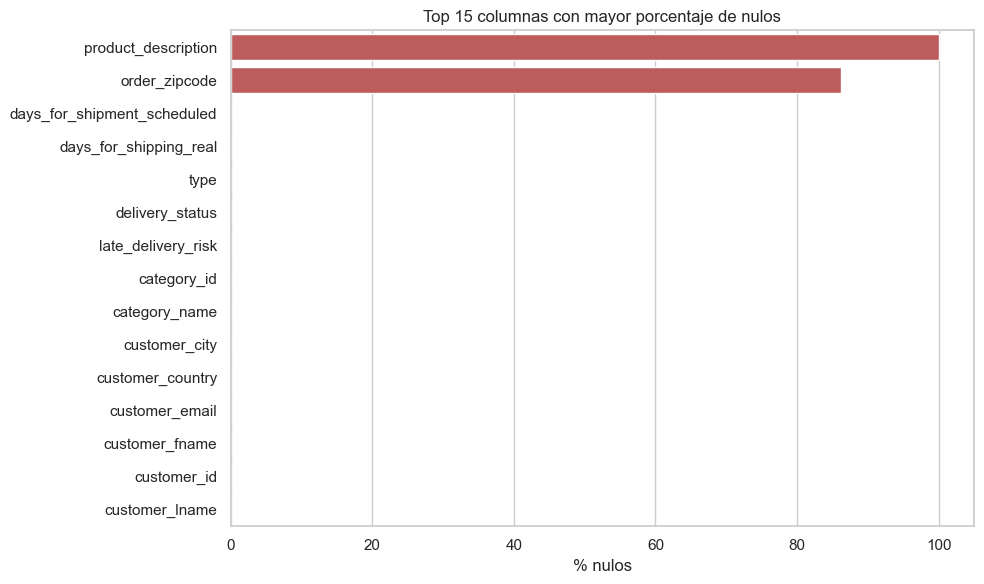

In [9]:
# Visualización de las 15 columnas con más nulos
if not nulos.empty:
    top_nulos = nulos.head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=top_nulos, x='pct_nulos', y='columna', ax=ax, color='#cc4c4c')
    ax.set_title('Top 15 columnas con mayor porcentaje de nulos')
    ax.set_xlabel('% nulos')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print('No hay columnas con nulos.')

## 5. Conversión de fechas y duplicados

In [10]:
df = convertir_fechas(df)
df[['order_date_dateorders', 'shipping_date_dateorders']].dtypes

2026-05-19 23:47:21 | INFO     | src.preprocessing:convertir_fechas:268 - Columna 'order_date_dateorders' convertida a datetime correctamente


2026-05-19 23:47:22 | INFO     | src.preprocessing:convertir_fechas:268 - Columna 'shipping_date_dateorders' convertida a datetime correctamente


order_date_dateorders       datetime64[ns]
shipping_date_dateorders    datetime64[ns]
dtype: object

In [11]:
print(f"Rango de fechas (orden):    {df['order_date_dateorders'].min()}  ->  {df['order_date_dateorders'].max()}")
print(f"Rango de fechas (envío):   {df['shipping_date_dateorders'].min()}  ->  {df['shipping_date_dateorders'].max()}")

Rango de fechas (orden):    2015-01-01 00:00:00  ->  2018-01-31 23:38:00
Rango de fechas (envío):   2015-01-03 00:00:00  ->  2018-02-06 22:14:00


In [12]:
df = eliminar_duplicados(df)
df.shape

2026-05-19 23:47:23 | INFO     | src.preprocessing:eliminar_duplicados:285 - No se detectaron duplicados


(180519, 53)

## 6. Distribución de la variable objetivo: `late_delivery_risk`

Esta es la variable que alimentará el clasificador de retrasos en `src/train_model.py`.

In [13]:
target = 'late_delivery_risk'
distribucion = df[target].value_counts(normalize=True).sort_index()
print('Distribución de la variable objetivo:')
print(distribucion.apply(lambda x: f'{x:.2%}'))
print(f'\nTotal de registros positivos (1): {df[target].sum():,}')
print(f'Total de registros negativos (0): {(df[target]==0).sum():,}')

Distribución de la variable objetivo:
late_delivery_risk
0    45.17%
1    54.83%
Name: proportion, dtype: object

Total de registros positivos (1): 98,977
Total de registros negativos (0): 81,542


C:\Users\paula\AppData\Local\Temp\ipykernel_36800\647328960.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target, ax=axes[0], palette=['#4c8acc', '#cc4c4c'])


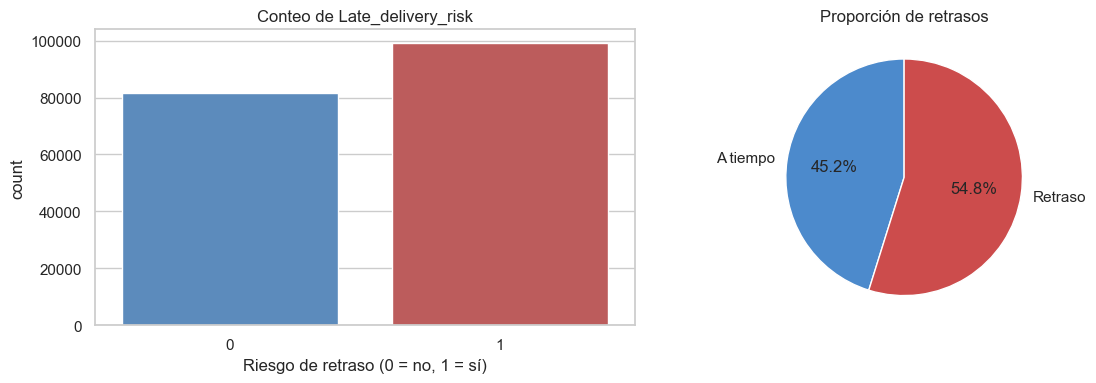

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x=target, ax=axes[0], palette=['#4c8acc', '#cc4c4c'])
axes[0].set_title('Conteo de Late_delivery_risk')
axes[0].set_xlabel('Riesgo de retraso (0 = no, 1 = sí)')

axes[1].pie(
    distribucion.values,
    labels=['A tiempo', 'Retraso'],
    autopct='%1.1f%%',
    colors=['#4c8acc', '#cc4c4c'],
    startangle=90,
)
axes[1].set_title('Proporción de retrasos')
plt.tight_layout()
plt.show()

### Relación entre `delivery_status` y `late_delivery_risk`

In [15]:
if 'delivery_status' in df.columns:
    tabla = pd.crosstab(df['delivery_status'], df[target], normalize='index') * 100
    print('% de retraso por estado de entrega:')
    print(tabla.round(2))

% de retraso por estado de entrega:
late_delivery_risk      0      1
delivery_status                 
Advance shipping   100.00   0.00
Late delivery        0.00 100.00
Shipping canceled  100.00   0.00
Shipping on time   100.00   0.00


## 7. Histogramas de variables numéricas clave

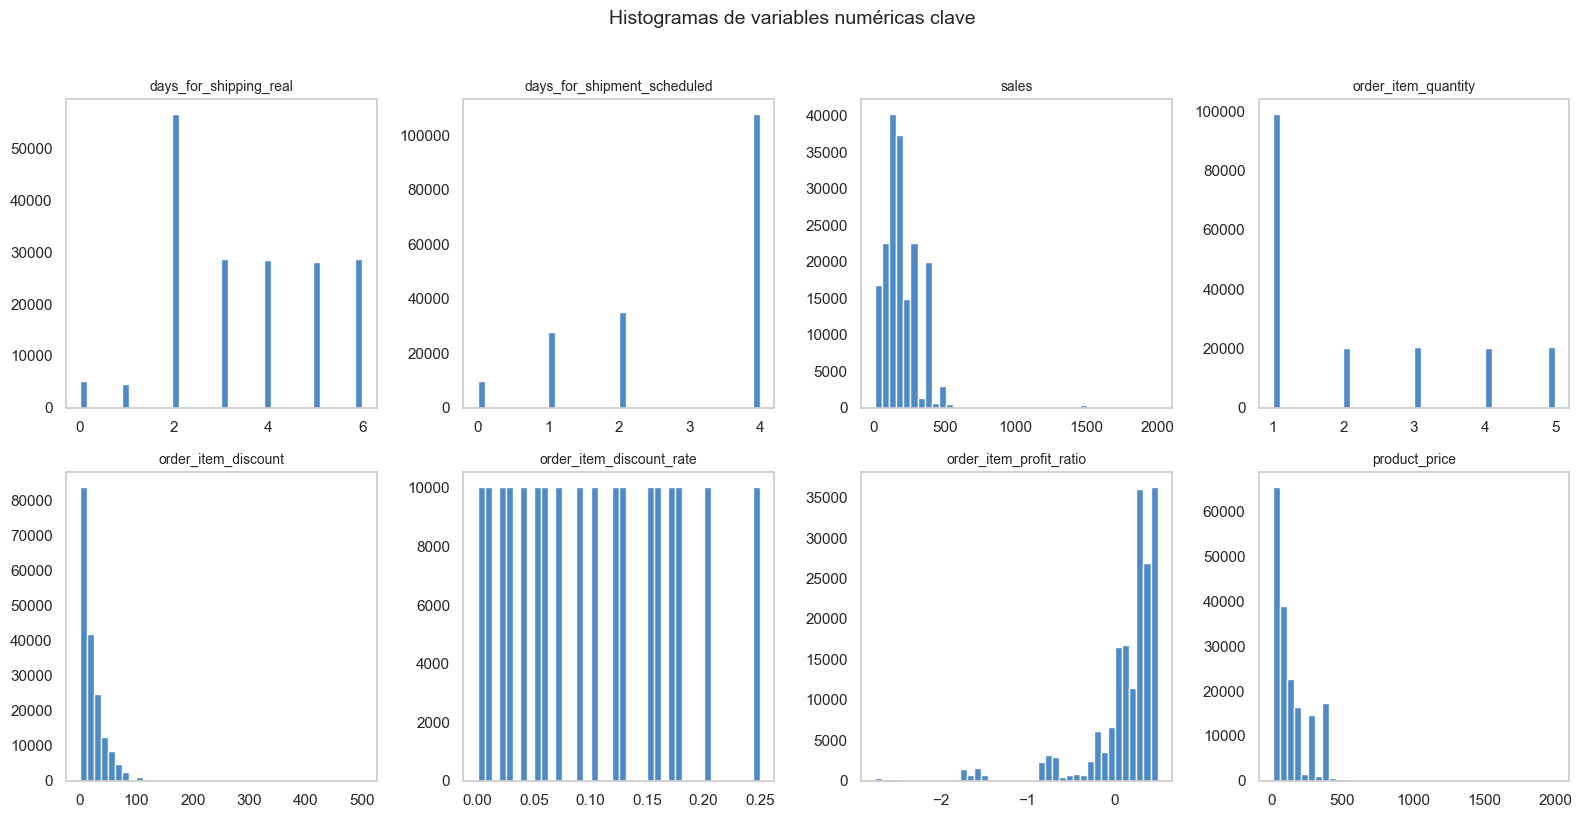

In [16]:
columnas_clave = [
    'days_for_shipping_real',
    'days_for_shipment_scheduled',
    'sales',
    'order_item_quantity',
    'order_item_discount',
    'order_item_discount_rate',
    'order_item_profit_ratio',
    'product_price',
]
columnas_clave = [c for c in columnas_clave if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, columnas_clave):
    df[col].hist(bins=40, ax=ax, color='#4c8acc', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.grid(False)
for ax in axes.flat[len(columnas_clave):]:
    ax.axis('off')
plt.suptitle('Histogramas de variables numéricas clave', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Días de envío real vs. programado

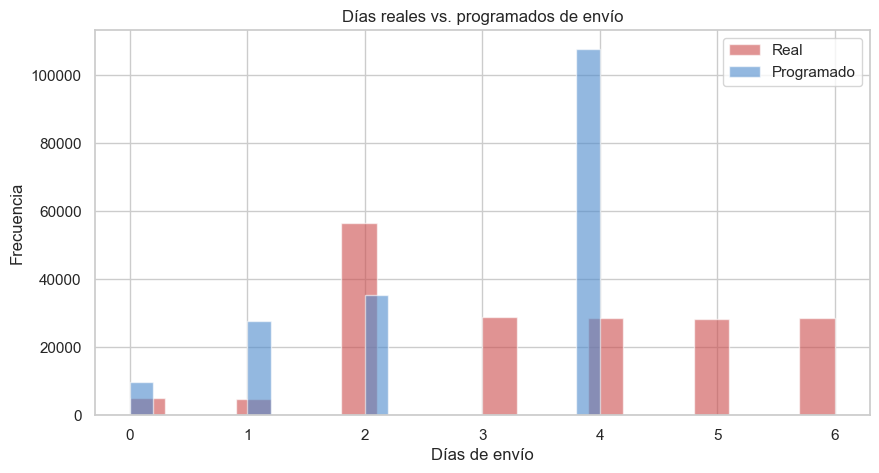

Diferencia promedio (real - programado): 0.57 días
% órdenes con días reales > programados: 57.28%


In [17]:
if {'days_for_shipping_real', 'days_for_shipment_scheduled'}.issubset(df.columns):
    fig, ax = plt.subplots(figsize=(10, 5))
    df['days_for_shipping_real'].hist(bins=20, alpha=0.6, label='Real', ax=ax, color='#cc4c4c')
    df['days_for_shipment_scheduled'].hist(bins=20, alpha=0.6, label='Programado', ax=ax, color='#4c8acc')
    ax.set_xlabel('Días de envío')
    ax.set_ylabel('Frecuencia')
    ax.set_title('Días reales vs. programados de envío')
    ax.legend()
    plt.show()
    
    diferencia = df['days_for_shipping_real'] - df['days_for_shipment_scheduled']
    print(f'Diferencia promedio (real - programado): {diferencia.mean():.2f} días')
    print(f'% órdenes con días reales > programados: {(diferencia > 0).mean():.2%}')

## 8. Matriz de correlaciones (numéricas)

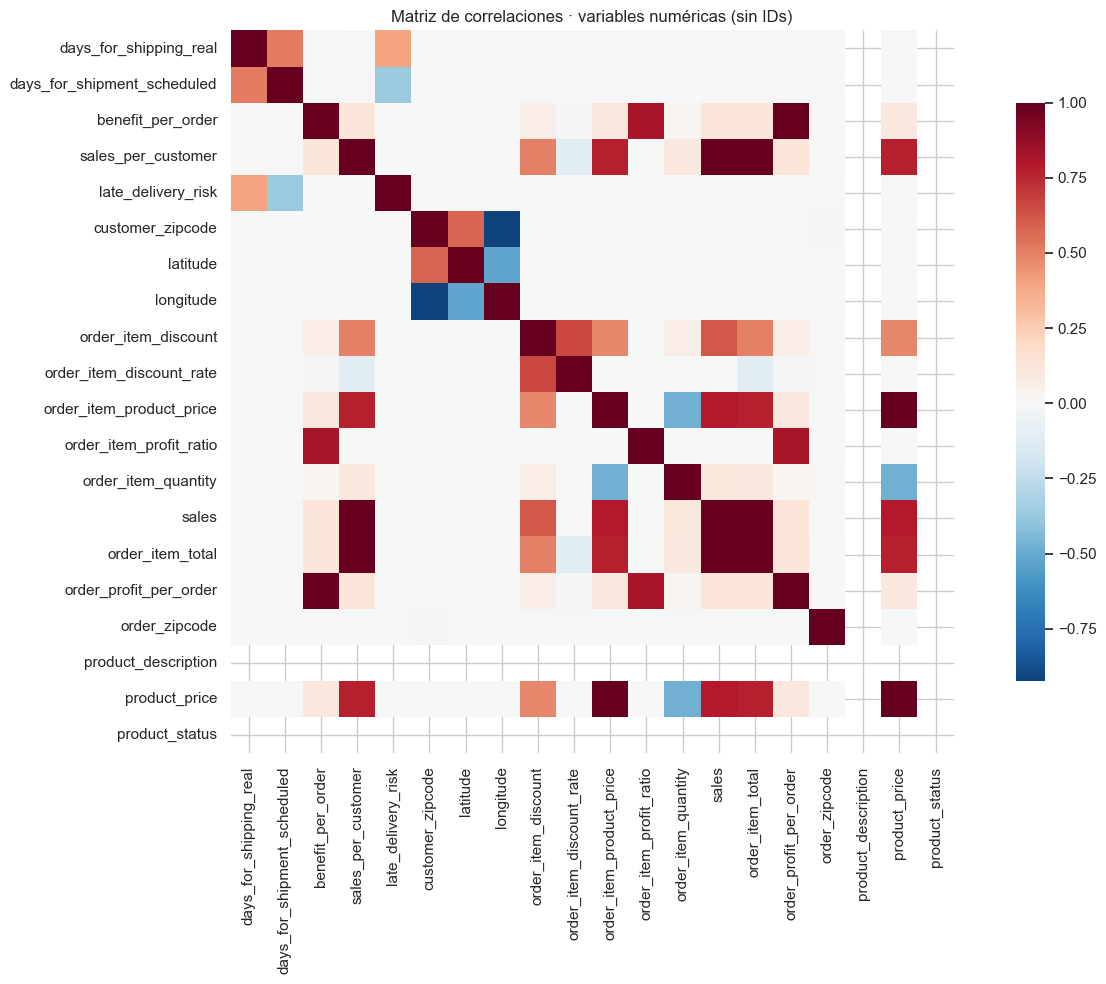

In [18]:
df_num = df.select_dtypes(include=[np.number])
# Eliminamos IDs porque sesgan la correlación
cols_id = [c for c in df_num.columns if c.endswith('_id') or c == 'product_card_id']
df_num = df_num.drop(columns=cols_id, errors='ignore')

corr = df_num.corr()
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap='RdBu_r',
    center=0,
    annot=False,
    square=True,
    cbar_kws={'shrink': 0.8},
    ax=ax,
)
ax.set_title('Matriz de correlaciones · variables numéricas (sin IDs)')
plt.tight_layout()
plt.show()

### Top variables correlacionadas con la variable objetivo

In [19]:
if target in corr.columns:
    corr_target = (
        corr[target]
        .drop(target)
        .abs()
        .sort_values(ascending=False)
        .head(15)
    )
    print('Top 15 variables más correlacionadas con late_delivery_risk:')
    print(corr_target.round(3))

Top 15 variables más correlacionadas con late_delivery_risk:
days_for_shipping_real        0.40
days_for_shipment_scheduled   0.37
order_zipcode                 0.01
order_item_total              0.00
sales_per_customer            0.00
order_profit_per_order        0.00
benefit_per_order             0.00
sales                         0.00
customer_zipcode              0.00
order_item_profit_ratio       0.00
order_item_product_price      0.00
product_price                 0.00
longitude                     0.00
order_item_discount           0.00
latitude                      0.00
Name: late_delivery_risk, dtype: float64


## 9. Análisis inicial: retrasos por segmento

Exploramos cómo varía la tasa de retraso por **modo de envío**, **mercado**, **región** y **segmento de cliente**.

In [20]:
def tasa_retraso_por(columna):
    if columna not in df.columns:
        return None
    agg = (
        df.groupby(columna)[target]
        .agg(['count', 'mean'])
        .rename(columns={'count': 'ordenes', 'mean': 'tasa_retraso'})
        .sort_values('tasa_retraso', ascending=False)
    )
    return agg

for col in ['shipping_mode', 'market', 'order_region', 'customer_segment']:
    resumen = tasa_retraso_por(col)
    if resumen is not None:
        print(f'\n--- Tasa de retraso por {col} ---')
        print(resumen.head(10))


--- Tasa de retraso por shipping_mode ---
                ordenes  tasa_retraso
shipping_mode                        
First Class       27814          0.95
Second Class      35216          0.77
Same Day           9737          0.46
Standard Class   107752          0.38

--- Tasa de retraso por market ---
              ordenes  tasa_retraso
market                             
Europe          50252          0.55
Pacific Asia    41260          0.55
USCA            25799          0.55
Africa          11614          0.55
LATAM           51594          0.54

--- Tasa de retraso por order_region ---
                ordenes  tasa_retraso
order_region                         
Central Africa     1677          0.58
South Asia         7731          0.56
East Africa        1852          0.56
Western Europe    27109          0.56
South of  USA      4045          0.56
Eastern Europe     3920          0.56
East of USA        6915          0.56
Southeast Asia     9539          0.56
Central Asia       

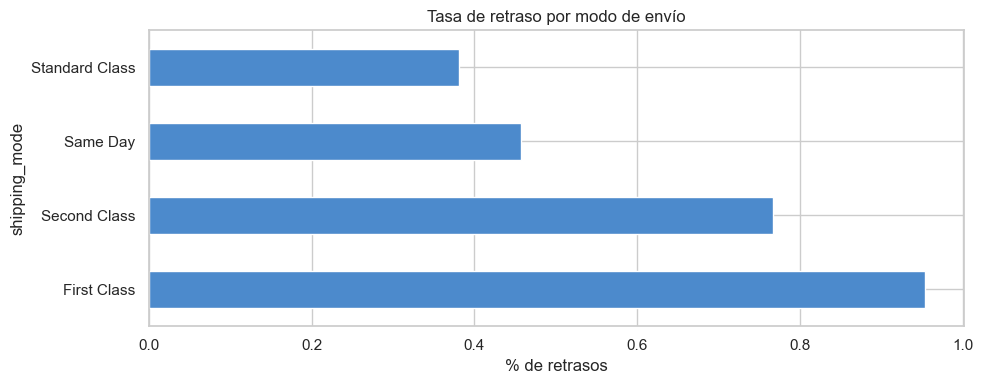

In [21]:
if 'shipping_mode' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    (
        df.groupby('shipping_mode')[target].mean()
        .sort_values(ascending=False)
        .plot(kind='barh', ax=ax, color='#4c8acc')
    )
    ax.set_title('Tasa de retraso por modo de envío')
    ax.set_xlabel('% de retrasos')
    plt.tight_layout()
    plt.show()

## 10. Riesgo de fuga de información

Antes del modelado conviene identificar variables que podrían introducir **data leakage**: columnas que codifican información disponible solo después del despacho o incluso después de conocer el resultado final de la entrega.

Especial atención:

- `delivery_status`: suele reflejar directamente el estado final de entrega.
- `days_for_shipping_real`: es una variable muy predictiva, pero puede no estar disponible en un escenario ex-ante.
- Variables derivadas de fechas o del cumplimiento real deben diferenciarse de las que sí están disponibles al momento de prometer el servicio.

In [22]:
columnas_potencial_leakage = [
    'delivery_status',
    'days_for_shipping_real',
    'shipping_date_dateorders',
]

presentes = [c for c in columnas_potencial_leakage if c in df.columns]
print('Columnas con potencial de fuga presentes en el dataset:')
print(presentes)

if 'delivery_status' in df.columns:
    tabla_status = (
        pd.crosstab(df['delivery_status'], df[target], normalize='index') * 100
    ).round(2)
    print('\nImpacto de delivery_status sobre la variable objetivo (% por clase):')
    print(tabla_status)

if {'days_for_shipping_real', 'days_for_shipment_scheduled'}.issubset(df.columns):
    comparacion = pd.DataFrame({
        'promedio_real': [df['days_for_shipping_real'].mean()],
        'promedio_programado': [df['days_for_shipment_scheduled'].mean()],
        'pct_real_mayor_programado': [
            (
                df['days_for_shipping_real']
                > df['days_for_shipment_scheduled']
            ).mean() * 100
        ],
    })
    print('\nSeñal de fuga potencial asociada a tiempos reales de entrega:')
    display(comparacion.round(2))

print(
    '\nRecomendación: para el baseline ex-ante conviene excluir columnas que '
    'solo se conocen tras la entrega o que resumen directamente el resultado final.'
)

Columnas con potencial de fuga presentes en el dataset:
['delivery_status', 'days_for_shipping_real', 'shipping_date_dateorders']

Impacto de delivery_status sobre la variable objetivo (% por clase):
late_delivery_risk      0      1
delivery_status                 
Advance shipping   100.00   0.00
Late delivery        0.00 100.00
Shipping canceled  100.00   0.00
Shipping on time   100.00   0.00

Señal de fuga potencial asociada a tiempos reales de entrega:


,promedio_real,promedio_programado,pct_real_mayor_programado
0,3.50,2.93,57.28



Recomendación: para el baseline ex-ante conviene excluir columnas que solo se conocen tras la entrega o que resumen directamente el resultado final.


## 11. Análisis geográfico y señal externa

El comportamiento del retraso no solo depende de variables operativas. También puede variar por **país**, **mercado** y **región**, lo que abre la puerta a enriquecer el modelo con fuentes externas como clima, estacionalidad o indicadores territoriales.

En esta fase el objetivo no es integrar aún esas fuentes, sino verificar si existe heterogeneidad geográfica suficiente para justificar ese enriquecimiento.


--- Top 10 segmentos geográficos por order_country ---


,ordenes,tasa_retraso
order_country,,
Luxemburgo,10,1.00
Laos,6,1.00
Armenia,5,1.00
Bután,5,1.00
República de Gambia,5,1.00
Suazilandia,5,1.00
Sudán del Sur,5,1.00
Eritrea,2,1.00
Guinea Ecuatorial,2,1.00



--- Top 10 segmentos geográficos por market ---


,ordenes,tasa_retraso
market,,
Europe,50252,0.55
Pacific Asia,41260,0.55
USCA,25799,0.55
Africa,11614,0.55
LATAM,51594,0.54



--- Top 10 segmentos geográficos por order_region ---


,ordenes,tasa_retraso
order_region,,
Central Africa,1677,0.58
South Asia,7731,0.56
East Africa,1852,0.56
Western Europe,27109,0.56
South of USA,4045,0.56
Eastern Europe,3920,0.56
East of USA,6915,0.56
Southeast Asia,9539,0.56
Central Asia,553,0.55


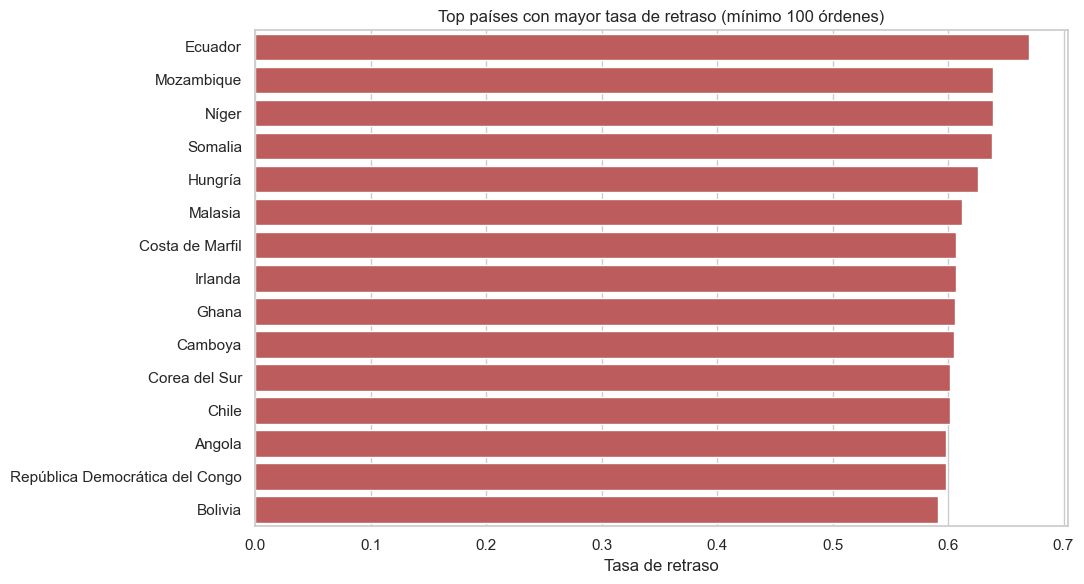


Lectura de negocio: si estas diferencias se sostienen en el tiempo, vale la pena complementar el modelo con variables externas como clima, temporalidad o condiciones por mercado.


In [23]:
columnas_geo = ['order_country', 'market', 'order_region']
columnas_geo = [c for c in columnas_geo if c in df.columns]

for col in columnas_geo:
    resumen_geo = (
        df.groupby(col)[target]
        .agg(['count', 'mean'])
        .rename(columns={'count': 'ordenes', 'mean': 'tasa_retraso'})
        .sort_values(['tasa_retraso', 'ordenes'], ascending=[False, False])
    )
    print(f'\n--- Top 10 segmentos geográficos por {col} ---')
    display(resumen_geo.head(10).round(4))

if 'order_country' in df.columns:
    top_paises = (
        df.groupby('order_country')[target]
        .agg(['count', 'mean'])
        .rename(columns={'count': 'ordenes', 'mean': 'tasa_retraso'})
        .query('ordenes >= 100')
        .sort_values('tasa_retraso', ascending=False)
        .head(15)
    )

    if not top_paises.empty:
        fig, ax = plt.subplots(figsize=(11, 6))
        sns.barplot(
            data=top_paises.reset_index(),
            x='tasa_retraso',
            y='order_country',
            ax=ax,
            color='#cc4c4c',
        )
        ax.set_title('Top países con mayor tasa de retraso (mínimo 100 órdenes)')
        ax.set_xlabel('Tasa de retraso')
        ax.set_ylabel('')
        plt.tight_layout()
        plt.show()

print(
    '\nLectura de negocio: si estas diferencias se sostienen en el tiempo, '
    'vale la pena complementar el modelo con variables externas como clima, '
    'temporalidad o condiciones por mercado.'
)

## 13. Ejecutar pipeline de limpieza y guardar

Aplica todo el pipeline orquestado y persiste el resultado en `data/processed/dataco_clean.parquet`.

In [24]:
df_limpio = limpiar_dataco(
    nombre_archivo='DataCoSupplyChainDataset.csv',
    guardar=True,
    nombre_salida='dataco_clean.parquet',
    imputar=False,
)
df_limpio.shape

2026-05-19 23:47:30 | INFO     | src.preprocessing:limpiar_dataco:420 - ============================================================


2026-05-19 23:47:30 | INFO     | src.preprocessing:limpiar_dataco:421 - INICIO DEL PIPELINE DE LIMPIEZA — DATACO


2026-05-19 23:47:30 | INFO     | src.preprocessing:limpiar_dataco:422 - ============================================================


2026-05-19 23:47:30 | INFO     | src.preprocessing:cargar_dataco:113 - Cargando dataset DataCo desde: C:\Users\paula\Documents\udemedellin\pryectofinal\smartdelayai360\data\raw\DataCoSupplyChainDataset.csv


2026-05-19 23:47:33 | SUCCESS  | src.preprocessing:cargar_dataco:119 - Dataset cargado con encoding 'latin-1' | shape=(180519, 53)


...

2026-05-19 23:47:39 | SUCCESS  | src.preprocessing:guardar_dataset_procesado:374 - Dataset limpio guardado: C:\Users\paula\Documents\udemedellin\pryectofinal\smartdelayai360\data\processed\dataco_clean.parquet (180,519 filas, 45 columnas, 8.59 MB)


2026-05-19 23:47:39 | INFO     | src.preprocessing:limpiar_dataco:462 - ============================================================


2026-05-19 23:47:39 | SUCCESS  | src.preprocessing:limpiar_dataco:463 - PIPELINE COMPLETADO | (180519, 53) -> (180519, 45)


2026-05-19 23:47:39 | INFO     | src.preprocessing:limpiar_dataco:467 - ============================================================


(180519, 45)

In [25]:
df_limpio.head()

,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,customer_country,customer_id,customer_segment,customer_state,department_id,department_name,latitude,longitude,market,order_city,order_country,order_customer_id,order_date_dateorders,order_id,order_item_cardprod_id,order_item_discount,order_item_discount_rate,order_item_id,order_item_product_price,order_item_profit_ratio,order_item_quantity,sales,order_item_total,order_profit_per_order,order_region,order_state,order_status,order_zipcode,product_card_id,product_category_id,product_name,product_price,product_status,shipping_date_dateorders,shipping_mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,20755,Consumer,PR,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,19492,Consumer,PR,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,NaN,1360,73,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,19491,Consumer,CA,2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,19491,2018-01-13 12:06:00,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,NaN,1360,73,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,19490,Home Office,CA,2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,19490,2018-01-13 11:45:00,75937,1360,22.94,0.07,179252,327.75,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,NaN,1360,73,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,19489,Corporate,PR,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,19489,2018-01-13 11:24:00,75936,1360,29.50,0.09,179251,327.75,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class
